# Trabajo Practico 4 - Medidas Electrónicas 1
**Docentes:**

*   Ing. Marinsek, Emiliano
*   Ing. Perdomo, Juan Manuel

**Alumnos:**

*   Ferrario, Franco Ezequiel
*   Encinas, Leandro
*   Marchesi, Matias
*   Quiroga, Bruno

**Curso:** R4052

**Año:** 2026


# Librerias y funciones a utilizar

In [2]:
# Librerias de pyhon a utilizar
import numpy as np
import math
import IPython
from IPython.display import display, Math
import pandas as pd
from typing import Any


def incert_A(mediciones):
  s = np.std(mediciones, ddof=1, )  # ddof=1 -> grados de libertad v = 1/n-1
  return s/math.sqrt(len(mediciones))

def incert_B(err_rel, nd, ctas, mediciones):
  return (err_rel/100 + nd/ctas) * np.mean(mediciones) / math.sqrt(3)


def incert_B_ConMedia(err_rel, nd, ctas, media):
  return (err_rel/100 + nd/ctas) * media / math.sqrt(3)

def incert_Total(uA, uB):
  return math.sqrt(uA**2 + uB**2)

def incert_Comb_Rel(uX, uY,correlacion=0):
  return math.sqrt((uX['u_C']/uX['media'])**2 + (uY['u_C']/uY['media'])**2 - (2*(uX['u_C']/uX['media'])*(uY['u_C']/uY['media'])*correlacion))

# Ejercicio 1
Medición de impedancia.

Se busca medir la impedancia de un dipolo paralelo conformado por un  capacitor y una resistencia cuya fase se encuentra entre 25º/40º a una frecuencia de 1kHz. Para ello se propone medir la tensión y corriente del dipolo utilizando un DSO y un resistencia en serie para medir la corriente.
Nota: Tenga cuidado de definir las resistencias para que las mediciones de  tensión esté en la misma escala y de no cortocircuitar las masas del DSO.


Cálculo teórico (Se realizó con f=10kHz):

$Z_P$ = $\frac{R_2}{1+- j \omega C R_2 }$

$Z_{Total}$ = $R_1$ + $\frac{R_2}{1+ j \omega C R_2 }$

$Z_{Total}$ = ($R_1$ + $\frac{R_2}{1+ (\omega C R_2)^2 }$) - j ($\frac{\omega C R_2^2}{1+ (\omega C R_2)^2 }$)

$H$ = $\frac{V_{Out}}{V_{In}}$ = $\frac{Z_{P}}{Z_{Total}}$
$H$ = $\frac{247.05 - j 1552.23}{1247.05 -j1552.23}$

$\theta_{num}$ = arctan($\frac{-1552.23}{247.05}$) = $-80.96º$
$\theta_{den}$ = arctan($\frac{-1552.23}{1247.05}$) = $-51.22º$

$\phi$ = $\theta_{num}$ - $\theta_{den}$ = $-80.96º$  $+51.22º$ = $-29.74º$

$\Delta{t}$ = $\frac{|\phi|}{360º * f}$ =$8.26\mu s$

# Medición y cálculos del laboratorio

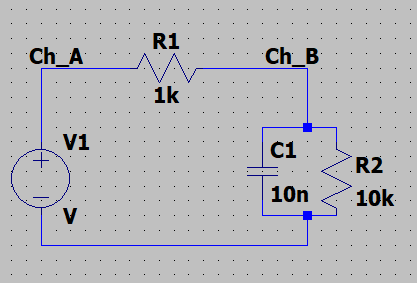

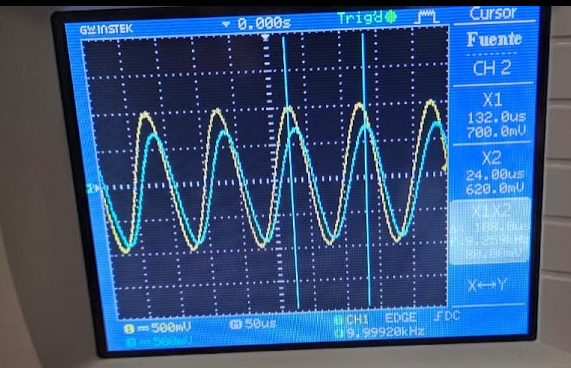

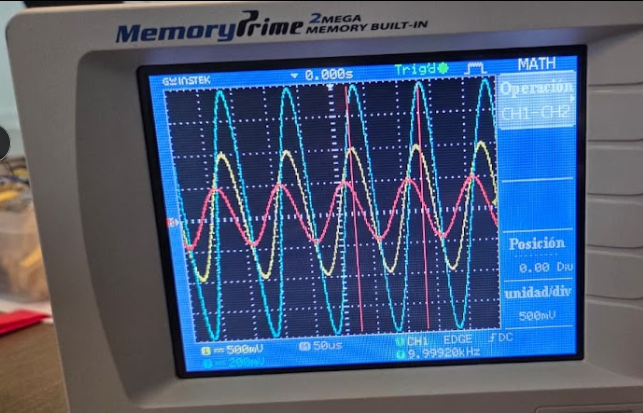

In [3]:
delta_t = 8e-6 #s
esc_hor = 50e-6  #s/div
res_cursores = 0.1e-6 #s Resolucion del cursor

u_base_tiempo = (delta_t * 0.01)/(100*math.sqrt(3))

u_res_dig = math.sqrt(((res_cursores/2)/math.sqrt(3))**2+((res_cursores/2)/math.sqrt(3))**2)

u_medicion_visual = (res_cursores)/math.sqrt(3)

u_c = math.sqrt(u_base_tiempo**2 + u_res_dig**2 + u_medicion_visual**2)
print("u(delta_t): "+ str(u_c))

print("U(delta_t): "+ str(u_c*2)) #k=2

print(f"Δt = ({delta_t*10**6:.2f} ± {(u_c*2)*10**6:.2f}) μs [k=2]")



u(delta_t): 7.071218659703102e-08
U(delta_t): 1.4142437319406204e-07
Δt = (8.00 ± 0.14) μs [k=2]


# Conclusion

Podemos ver que nuestro cálculo teórico está un poco por fuera de lo visto en el osciloscopio y esto podemos atribuirlo a la desviación de los componentes (resistencias y capacitor) del circuito que no son utilizados para el cálculo teórico pero esa variación nos hace variar los valores en el circuito real.

# Ejercicio 2
Mediciones de eventos únicos.

Utilizando un circuito conformado por un relé, un switch y un diodo removible se busca medir:


*   Tiempo de apertura y tiempo de cierre (con y sin diodo de protección)
*   Sobre-tensión en la llave en el momento de apertura (con y sin diodo de protección)




**Tiempo de establecimiento**

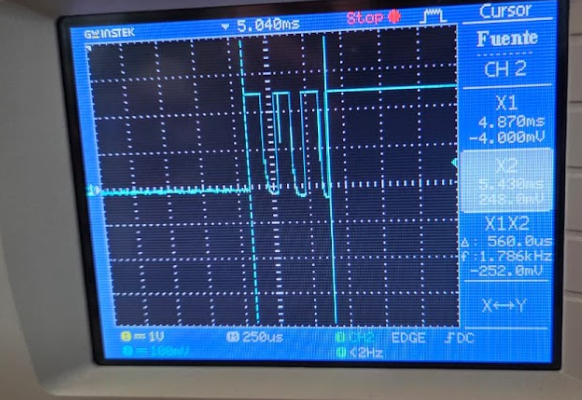

**Tiempo de establecimiento CON diodo**

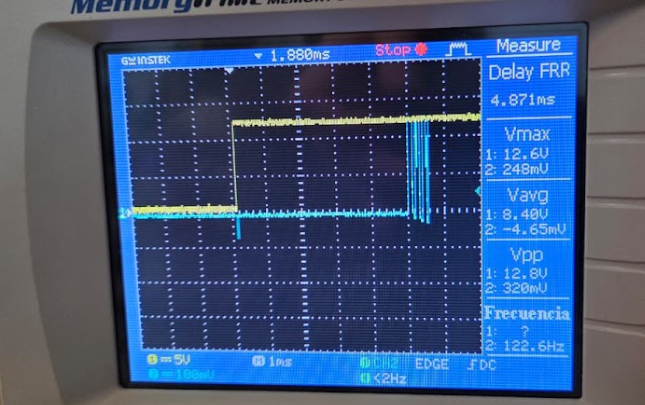


**Tiempo de establecimiento SIN diodo**

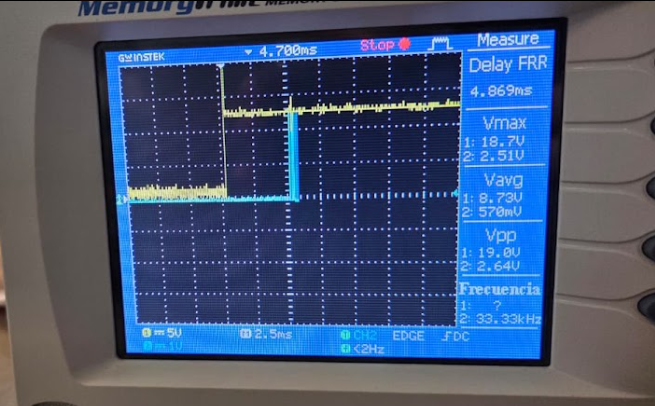

Sin diodo podemos observar un sobrepico de 18.7 $V_{PP}$ y un tiempo de establecimiento de 590 $ns$
Con diodo se puede observar un menor sobrepico, de 12.6 $V_{PP}$, pero el tiempo de establecimiento es de 560 $\mu s$


# Calculos de incertidumbre CON DIODO

In [4]:
import numpy as np
# INCERTIDUMBRE DEL TIEMPO DE ESTABLECIMIENTO
print("TIEMPO DE ESTABLECIMIENTO:")

# Datos iniciales
t_s = 560e-6  # 560 us en segundos
exactitud_horizontal = 0.01 / 100  # 0.01%

#incertidumbre (distribución rectangular)
delta_t = t_s * exactitud_horizontal
u_t_s = delta_t / np.sqrt(3)

# incertidumbre expandida (k=2)
k = 2
U_t_s = k * u_t_s

print(f"Valor observado (ts): {t_s * 1e6:.2f} us")
print(f"Incertidumbre estándar u(ts): {u_t_s * 1e9:.2f} ns")
print(f"Incertidumbre expandida U(ts) [k=2]: {U_t_s * 1e9:.2f} ns")
print(f"Resultado final: ({t_s * 1e6:.3f} ± {U_t_s * 1e6:.3f}) us\n")


# ==========================================
#INCERTIDUMBRE DEL SOBREPICO
# ==========================================
print("SOBREPICO:")

# Datos de tensión para el Canal 1
V_max = 12.6  # Voltios
V_div = 5.0   # Voltios por división (Escala vertical)
V_estable = 12.0  # Voltios (Valor final de régimen estable estimado)

# Especificaciones del Datasheet para Exactitud Vertical
# ±(3% * Lectura + 0.1 div + 1 mV)
error_lectura = 0.03 * V_max
error_division = 0.1 * V_div
error_fijo = 0.001

delta_V = error_lectura + error_division + error_fijo
u_V_max = delta_V / np.sqrt(3)

# Cálculo del sobrepico porcentual
overshoot = ((V_max - V_estable) / V_estable) * 100

# Propagación de incertidumbre según la GUM (Derivada parcial d(Overshoot)/dV_max)
# Coeficiente de sensibilidad c = 100 / V_estable
c_sensibilidad = 100 / V_estable
u_overshoot = c_sensibilidad * u_V_max

# Incertidumbre expandida (k=2)
U_overshoot = k * u_overshoot

print(f"Valor calculado de Overshoot: {overshoot:.2f}%")
print(f"Incertidumbre estándar u(Overshoot): {u_overshoot:.2f}%")
print(f"Incertidumbre expandida U(Overshoot) [k=2]: {U_overshoot:.2f}%")
print(f"Resultado final: Overshoot = ({overshoot:.1f} ± {U_overshoot:.1f})%")

TIEMPO DE ESTABLECIMIENTO:
Valor observado (ts): 560.00 us
Incertidumbre estándar u(ts): 32.33 ns
Incertidumbre expandida U(ts) [k=2]: 64.66 ns
Resultado final: (560.000 ± 0.065) us

SOBREPICO:
Valor calculado de Overshoot: 5.00%
Incertidumbre estándar u(Overshoot): 4.23%
Incertidumbre expandida U(Overshoot) [k=2]: 8.46%
Resultado final: Overshoot = (5.0 ± 8.5)%


# Calculos de Incertidumbre SIN DIODO

In [5]:
import numpy as np
# INCERTIDUMBRE DEL TIEMPO DE ESTABLECIMIENTO
print("TIEMPO DE ESTABLECIMIENTO:")

t_s = 590e-9  # 590 ns expresado en segundos
exactitud_horizontal = 0.01 / 100  # 0.01% según el datasheet

# Cálculo bajo distribución rectangular (GUM Tipo B)
delta_t = t_s * exactitud_horizontal
u_t_s = delta_t / np.sqrt(3)
k = 2
U_t_s = k * u_t_s

print(f"Valor observado (ts): {t_s * 1e9:.3f} ns")
print(f"Incertidumbre estándar u(ts): {u_t_s * 1e9:.3f} ns")
print(f"Incertidumbre expandida U(ts) [k=2]: {U_t_s * 1e9:.3f} ns")
print(f"Resultado final: ts = ({t_s * 1e9:.3f} ± {U_t_s * 1e9:.3f}) ns \n")


# ==========================================================
# INCERTIDUMBRE DEL SOBREPICO
# ==========================================================
print(" SOBREPICO:")

# Datos obtenidos de la pantalla para el Canal 1
V_max = 18.7      # Valor Vmax medido en pantalla (Voltios)
V_estable = 12.0  # Nivel de régimen permanente (3 divisiones x 5V/div = 12V)
V_div = 5.0       # Escala vertical (Voltios/división)

# Tolerancia vertical del instrumento: ±(3%*Lectura + 0.1 div + 1 mV)
error_lectura = 0.03 * V_max
error_division = 0.1 * V_div
error_fijo = 0.001

delta_V = error_lectura + error_division + error_fijo
u_V_max = delta_V / np.sqrt(3)

# Cálculo del sobrepico porcentual relativo al nivel estable
overshoot_porcentaje = ((V_max - V_estable) / V_estable) * 100

# Derivada parcial de Overshoot respecto a Vmax: c = 100 / V_estable
c_sensibilidad = 100 / V_estable
u_overshoot = c_sensibilidad * u_V_max
U_overshoot = k * u_overshoot

print(f"Valor Vmax: {V_max:.1f} V")
print(f"Incertidumbre estándar u(Vmax): {u_V_max:.4f} V")
print(f"Sobrepico calculado: {overshoot_porcentaje:.2f}%")
print(f"Incertidumbre estándar u(Overshoot): {u_overshoot:.2f}%")
print(f"Incertidumbre expandida U(Overshoot) [k=2]: {U_overshoot:.2f}%")
print(f"Resultado final: Overshoot = ({overshoot_porcentaje:.0f} ± {U_overshoot:.0f})%")

TIEMPO DE ESTABLECIMIENTO:
Valor observado (ts): 590.000 ns
Incertidumbre estándar u(ts): 0.034 ns
Incertidumbre expandida U(ts) [k=2]: 0.068 ns
Resultado final: ts = (590.000 ± 0.068) ns 

 SOBREPICO:
Valor Vmax: 18.7 V
Incertidumbre estándar u(Vmax): 0.6131 V
Sobrepico calculado: 55.83%
Incertidumbre estándar u(Overshoot): 5.11%
Incertidumbre expandida U(Overshoot) [k=2]: 10.22%
Resultado final: Overshoot = (56 ± 10)%


# Conclusiones
Podemos observar claramente que el no tener diodo en el circuito, nos da un sobrepico mayor, pero el tiempo de establecimiento es menor  gracias al sobrepico producido por la inducción de la bobina del relé. En contraparte, vemos que el circuito con diodo, si bien se retrasa más, es más seguro eléctricamente hablando, si la velocidad no es una prioridad para el circuito, ya que el sobrepico es menor pero el tiempo de establecimiento es bastante mayor.

# Ejercicio 3
Tiempo de establecimiento

Medir el tiempo de establecimiento de un generador de señal rectangular.

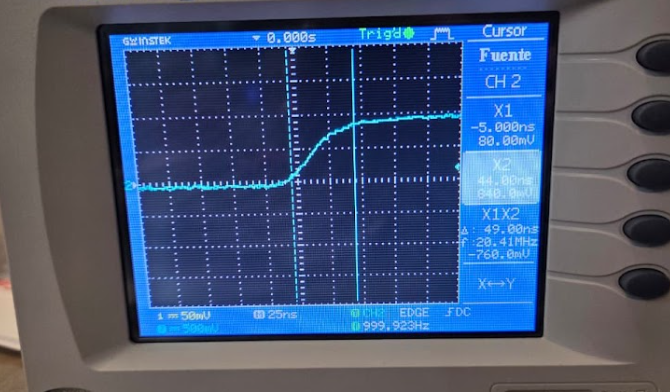

In [9]:
k=2
# ==========================================================
# INCERTIDUMBRE DEL TIEMPO DE ESTABLECIMIENTO / SUBIDA (49 ns)
# ==========================================================
print("TIEMPO DE ESTABLECIMIENTO")

t_s = 49.00e-9  # 49.00 ns expresado en segundos
exactitud_horizontal = 0.01 / 100  # 0.01% según el datasheet

# Incertidumbre
delta_t = t_s * exactitud_horizontal
u_t_s = delta_t / np.sqrt(3)
U_t_s = k * u_t_s

print(f"Valor medido con cursores (X1X2): {t_s * 1e9:.2f} ns")
print(f"Incertidumbre estándar u(ts): {u_t_s * 1e9:.6f} ns")
print(f"Incertidumbre expandida U(ts) [k=2]: {U_t_s * 1e9:.6f} ns")
print(f"Resultado final: ts = ({t_s * 1e9:.4f} ± {U_t_s * 1e9:.4f})ns")

TIEMPO DE ESTABLECIMIENTO
Valor medido con cursores (X1X2): 49.00 ns
Incertidumbre estándar u(ts): 0.002829 ns
Incertidumbre expandida U(ts) [k=2]: 0.005658 ns
Resultado final: ts = (49.0000 ± 0.0057)ns


# Conclusiones
Utilizando los cursores temporales del osciloscopio podemos ver que ubicándolos al 10% y al 90% del valor de la señal para calcular el rise time, obtenemos un valor de 49ns.
Para realizar esta medición se conectó el osciloscopio diréctamente al generador de señal.

# Ejercicio 4
Compensación de la punta

A partir de una señal senoidal de 100 kHz y Vpp = 4 V, medir el máximo error de tensión que se puede producir utilizando una punta sin compensar frente a otra compensada.  


Imagen del osciloscopio:

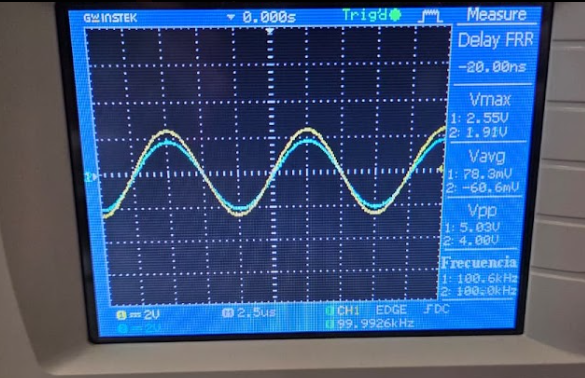

In [10]:
# Factor de cobertura
k = 2

print("COMPARATIVA DE PUNTAS DE PRUEBA:")

# Datos de la pantalla
Vpp_sin_compensar = 5.03  # CH1
Vpp_compensada = 4.00     # CH2
V_div = 2.0               # Escala vertical de 2 V/div para ambos

# Error medido directamente
error_medido = Vpp_sin_compensar - Vpp_compensada

# uB_CH1
delta_V1 = (0.03 * Vpp_sin_compensar) + (0.1 * V_div) + 0.001
u_V1 = delta_V1 / np.sqrt(3)

# uB_CH2
delta_V2 = (0.03 * Vpp_compensada) + (0.1 * V_div) + 0.001
u_V2 = delta_V2 / np.sqrt(3)

# Propagación de incertidumbre para la diferencia (Error = V1 - V2)
u_error = np.sqrt(u_V1**2 + u_V2**2)
U_error = k * u_error

# Máximo error posible (Límite superior del intervalo)
max_error_posible = error_medido + U_error

print(f"Error de tensión observado: {error_medido:.2f} V")
print(f"Incertidumbre expandida de la diferencia (k=2): ±{U_error:.2f} V")
print(f"Intervalo del error: ({error_medido:.2f} ± {U_error:.2f}) V")
print(f"MÁXIMO ERROR REAL QUE SE PUEDE PRODUCIR: {max_error_posible:.2f} V")

COMPARATIVA DE PUNTAS DE PRUEBA:
Error de tensión observado: 1.03 V
Incertidumbre expandida de la diferencia (k=2): ±0.55 V
Intervalo del error: (1.03 ± 0.55) V
MÁXIMO ERROR REAL QUE SE PUEDE PRODUCIR: 1.58 V


# Conclusiones
La falta de compensación en la punta de prueba del Canal 1 introdujo un error sistemático severo en la amplitud, registrando un valor de 5.03$V_{pp}$ frente a los 4.00$V_{pp}$ de la punta calibrada (un error medido de 1.03$V$). Al propagar las incertidumbres instrumentales, se determinó que la incertidumbre de la diferencia es de $0.55V_{pp}$, lo que sitúa al máximo error de tensión posible en $1.58V_{pp}$.
Esto nos hace notar que debemos compensar bien las puntas antes de cualquier medicion ya que sino distorsiona por completo el valor de la medicion.